In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import sys; sys.path.insert(0, '..')
from utils import parse_latencies, parse_power_log, get_power_index, plot_inference_cycle_power

In [2]:
DATA_PATH = Path('../../raw_data/power_profile_model_loading')
DELAY = 1 # delay introduced in seconds between inference cycles

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 4174621.6927380087


## Alexnet

In this section, we will analyse the power consumption of Alexnet model. We will look at how the power is consumed for each inference cycle.

We add a delay between inference cycle to distinguish between consecutive inference cycles.


In [4]:
model_name = 'alexnet'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
alexnet_power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
alexnet_latency_data = parse_latencies(data)

with open((DATA_PATH/model_name/f'{model_name}_tensorrt.json'), 'r') as fp:
    data = json.load(fp)
alexnet_data = data

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 35.17it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(alexnet_power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(alexnet_latency_data[0])}")
print(f"Number of latency entries for each layer: {len(alexnet_latency_data)}")

Number of power entries for alexnet: 2502032
Number of TensorRT layers in alexnet: 24
Number of latency entries for each layer: 3000


### Power Analysis

This is what the power plot looks like for 3000 inference cycles.

We see the power spikes in between 0.0 to 0.2 (1e6). This is where TorchTensorRT creates a TensorRT engine from PyTorch model. 

This part of the plot will be investigated as part of this notebook.

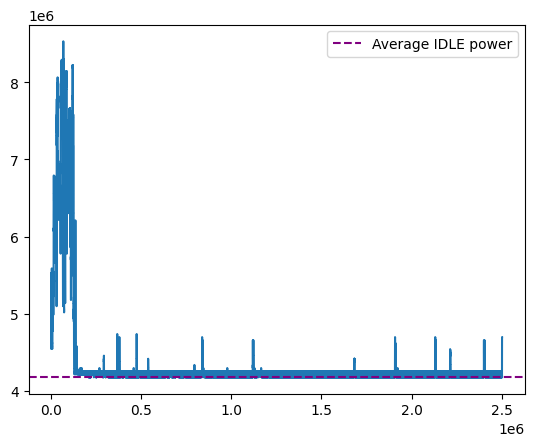

In [6]:
plt.plot([power for (timestamp, power) in alexnet_power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
plt.legend()

In [7]:
experiment_start_time = datetime.strptime(alexnet_data['timestamp'], "%Y%m%d-%H%M%S")
exp_start_time_index = get_power_index(alexnet_power_data, experiment_start_time)

pytorch_load_end_time = datetime.strptime(alexnet_data['pt_model_load_end'], "%Y%m%d-%H%M%S")
pytorch_load_end_index = get_power_index(alexnet_power_data, pytorch_load_end_time)

model_load_start_time = datetime.strptime(alexnet_data['model_load'][0], "%Y%m%d-%H%M%S")
model_load_start_index = get_power_index(alexnet_power_data, model_load_start_time)
model_load_end_time = datetime.strptime(alexnet_data['model_load'][1], "%Y%m%d-%H%M%S")
model_load_end_index = get_power_index(alexnet_power_data, model_load_end_time)

warmup_start_time = datetime.strptime(alexnet_data['warmup'][0], "%Y%m%d-%H%M%S")
warmup_start_index = get_power_index(alexnet_power_data, warmup_start_time)
warmup_end_time = datetime.strptime(alexnet_data['warmup'][1], "%Y%m%d-%H%M%S")
warmup_end_index = get_power_index(alexnet_power_data, warmup_end_time)

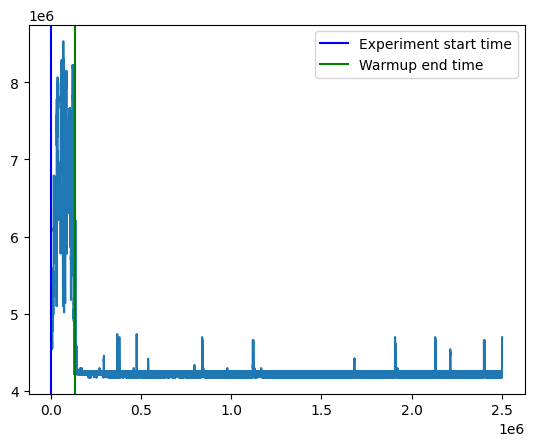

In [8]:
plt.plot([power for (timestamp, power) in alexnet_power_data])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(warmup_end_index, color='green', label='Warmup end time')
plt.legend()

### Observations

We will be looking at the intial spike in the power profile and breaking it down to understand what is happening in that phase.

We will capture timestamp when the 
- experiment has started
- model is being compiled and add a delay for 10 seconds
- when the warmup is being ran

The above timestamps will provide insights into what is going on with the initial timestamp.

The following plot shows the power profile when the experiment started and before the model is being compiled from PyTorch to TensorRT.

- The experiment starts at a higher power value which slowly decreases and increases.

What are things happening in this time?

- We get the PyTorch model downloaded
- Create dummy PyTorch input tensors
- Move both the model and the input tensors to GPU 

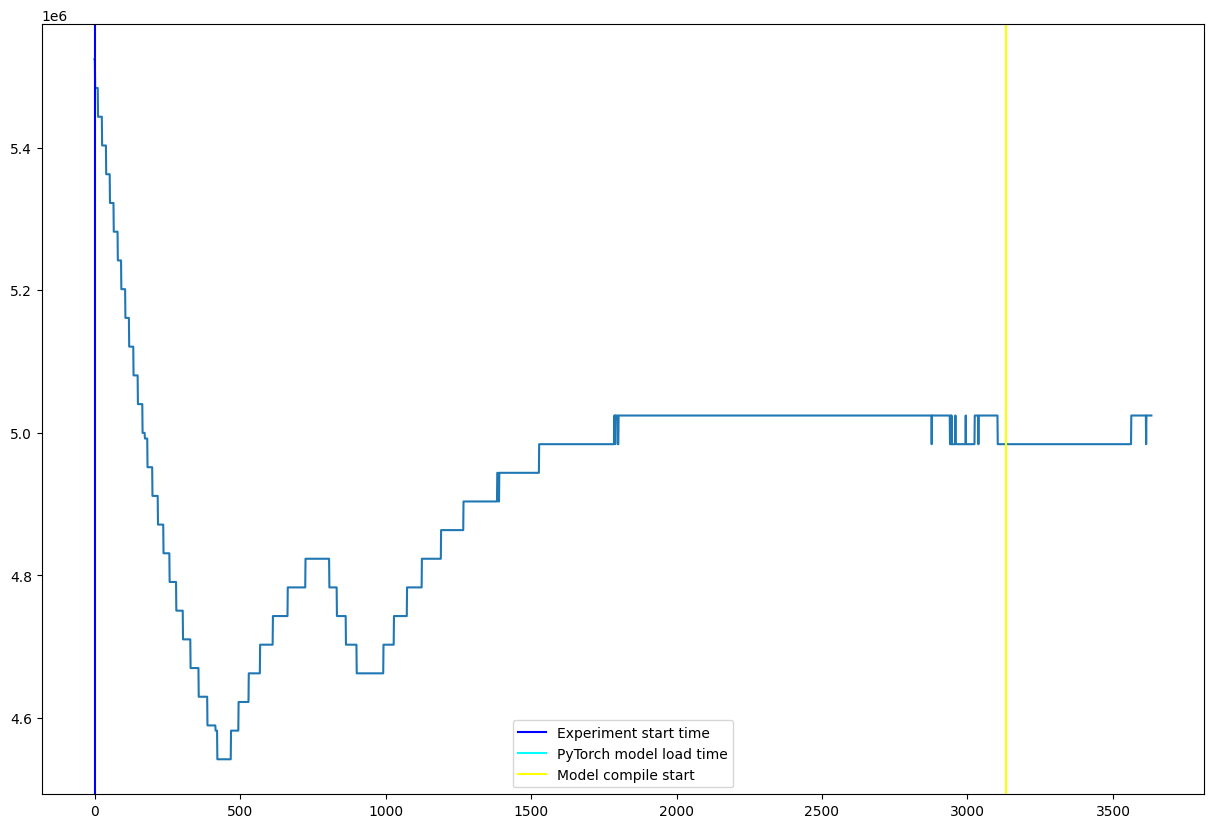

In [9]:
plt.figure(figsize=(15, 10))
plt.plot([power for (timestamp, power) in alexnet_power_data[:model_load_start_index+500]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(pytorch_load_end_index, color='cyan', label='PyTorch model load time')
plt.axvline(model_load_start_index, color='yellow', label='Model compile start')
plt.legend()

This is the most interesting plot that shows all the things happening before the actual inference starts.

1. Load the PyTorch model and peparate it for converting it to TensorRT. -> **This is the part between blue and yellow line.**
2. Convert the PyTorch model to TensorRT model. -> **This is the part between yellow and red line**.
3. A delay of 10 seconds is added as a cooldown from compilation. -> **This is the part between red and green line**.
4. A warmup of 100 runs is pretty fast. -> **This is the part between purple and green line**. It is fast so the lines are overlapping.

In the following section we break down the actual time taken by these processes as well.

We can also get the power consumed when the model is loaded which is 3rd part above between red and green line.
We get that power value to be `4213440.0`.

So we have power value 

- When jeston is idle : 4174621
- When TRT model is loaded: 4213440
- When inference is ran for 3000 runs: 4213440

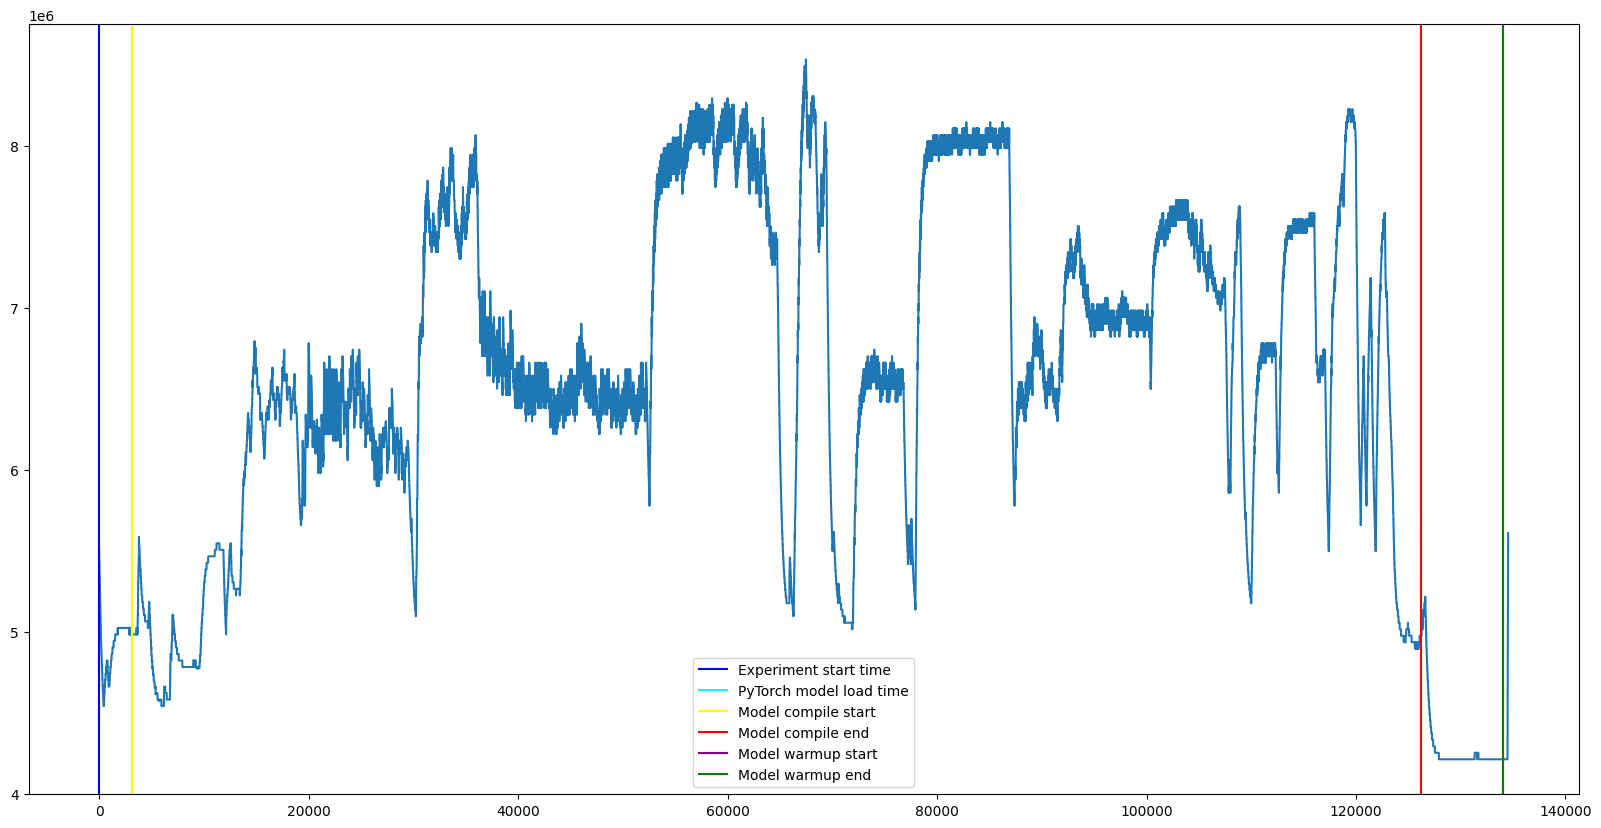

In [10]:
plt.figure(figsize=(20, 10))
plt.plot([power for (timestamp, power) in alexnet_power_data[:warmup_end_index+500]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(pytorch_load_end_index, color='cyan', label='PyTorch model load time')
plt.axvline(model_load_start_index, color='yellow', label='Model compile start')
plt.axvline(model_load_end_index, color='red', label='Model compile end')
plt.axvline(warmup_start_index, color='purple', label='Model warmup start')
plt.axvline(warmup_end_index, color='green', label='Model warmup end')
plt.legend()

In [11]:
print(f'Time taken to download and load the pytorch model: {(pytorch_load_end_time - experiment_start_time).total_seconds()} seconds')
print(f'Time taken to before the model compile starts and pytorch model is loaded: {(model_load_start_time - pytorch_load_end_time).total_seconds()} seconds')
print(f'Time taken to compile the TensorRT model: {(model_load_end_time - model_load_start_time).total_seconds()} seconds')
print(f'Sleep interval before the warmup starts: {(warmup_start_time - model_load_end_time).total_seconds()} seconds')
print(f'Time taken to run 100 runs of the warmup: {(warmup_end_time - warmup_start_time).total_seconds()} seconds')

Time taken to download and load the pytorch model: 5.0 seconds
Time taken to before the model compile starts and pytorch model is loaded: 0.0 seconds
Time taken to compile the TensorRT model: 163.0 seconds
Sleep interval before the warmup starts: 10.0 seconds
Time taken to run 100 runs of the warmup: 0.0 seconds


### Power cool down

This is the delay we introduce after the warmup ends and before the first iteration cycle beings for the benchmarking experiment.

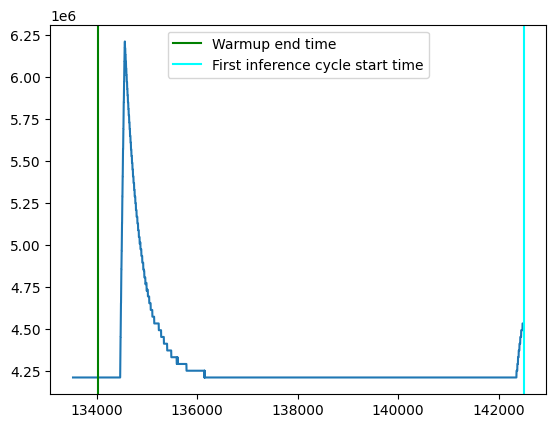

In [12]:
plt.plot(range(warmup_end_index-500, 142507), [power for (timestamp, power) in alexnet_power_data[warmup_end_index-500:142507]])
plt.axvline(warmup_end_index, color='green', label='Warmup end time')
plt.axvline(142507, color='cyan', label='First inference cycle start time')
plt.legend()

### Inference

Something else that is interesting is now the first cylce like the rest of the cycles has similar power profile for the inference.

By adding sufficient delays and allowing the power to cool down, we see that inference for 3000 runs consumes the same power for all cycles. 

> **The power consumed when the inference starts and when the delay of 1 second is completed is same for the majority of the runs.** This value is same as power consumed when TRT model is loaded.

> **The power consumed when the inference ends is higher than both the values above.** 

2025-01-22 14:30:10.805615 -> 2025-01-22 14:30:10.807876
2025-01-22 14:30:11.807876
Time taken by inference cycle 0: 0:00:00.002261
Iteration: 0, Power index: 142507 -> 142510
143294


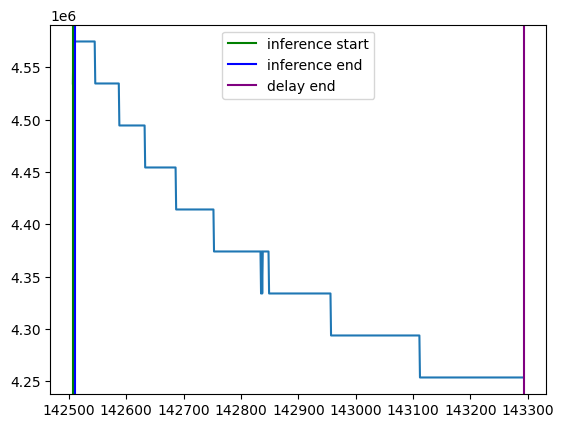

Power values:
Inference start: 4534464.0
Inference end: 4574592.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:11.810770 -> 2025-01-22 14:30:11.812956
2025-01-22 14:30:12.812956
Time taken by inference cycle 1: 0:00:00.002186
Iteration: 1, Power index: 143296 -> 143298
144083


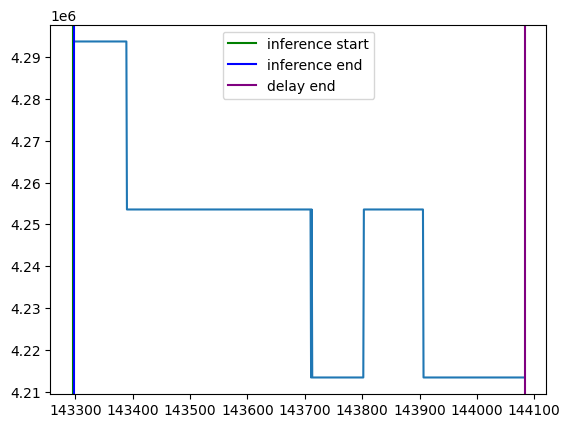

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:12.815855 -> 2025-01-22 14:30:12.818088
2025-01-22 14:30:13.818088
Time taken by inference cycle 2: 0:00:00.002233
Iteration: 2, Power index: 144084 -> 144087
144872


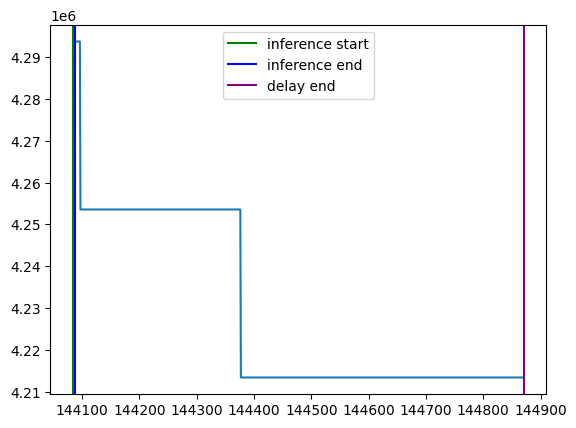

Power values:
Inference start: 4213440.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:13.820061 -> 2025-01-22 14:30:13.822298
2025-01-22 14:30:14.822298
Time taken by inference cycle 3: 0:00:00.002237
Iteration: 3, Power index: 144873 -> 144875
145660


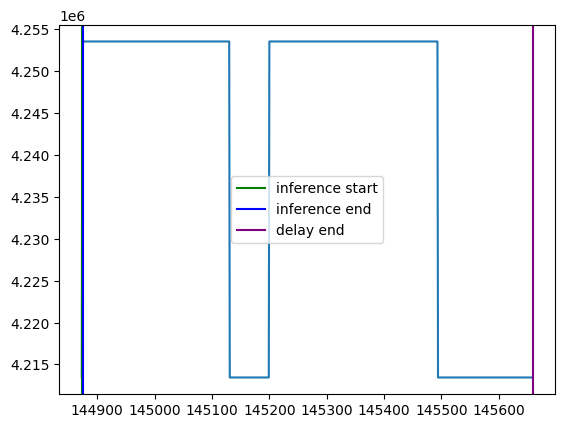

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:14.824917 -> 2025-01-22 14:30:14.827179
2025-01-22 14:30:15.827179
Time taken by inference cycle 4: 0:00:00.002262
Iteration: 4, Power index: 145661 -> 145664
146449


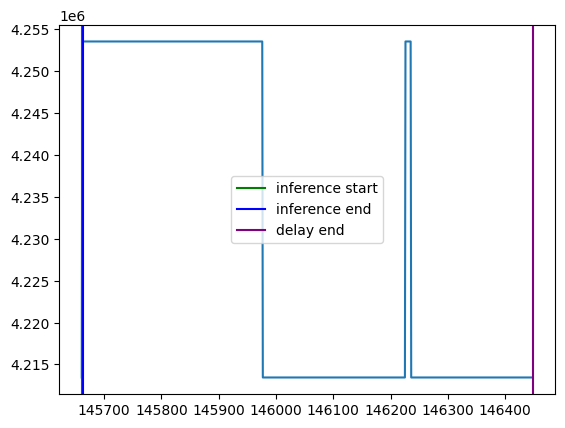

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:15.829637 -> 2025-01-22 14:30:15.831901
2025-01-22 14:30:16.831901
Time taken by inference cycle 5: 0:00:00.002264
Iteration: 5, Power index: 146450 -> 146452
147238


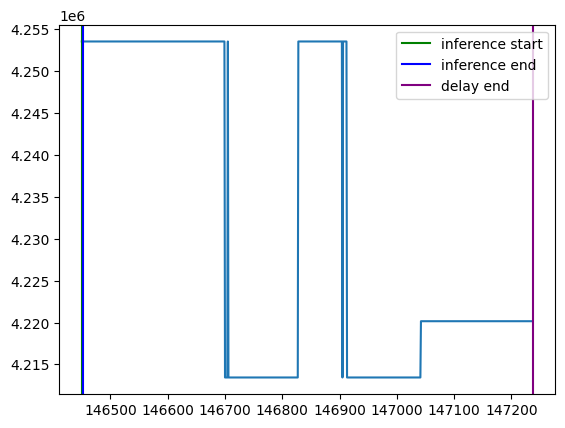

Power values:
Inference start: 4253568.0
Inference end: 4253568.0
Delay end: 4220160.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:16.834288 -> 2025-01-22 14:30:16.836556
2025-01-22 14:30:17.836556
Time taken by inference cycle 6: 0:00:00.002268
Iteration: 6, Power index: 147238 -> 147241
148026


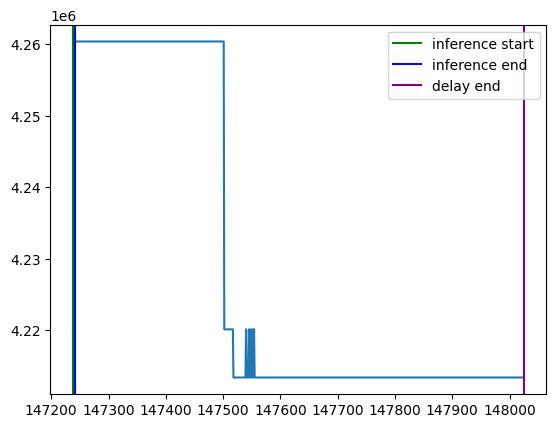

Power values:
Inference start: 4220160.0
Inference end: 4260352.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:17.839111 -> 2025-01-22 14:30:17.841357
2025-01-22 14:30:18.841357
Time taken by inference cycle 7: 0:00:00.002246
Iteration: 7, Power index: 148027 -> 148030
148815


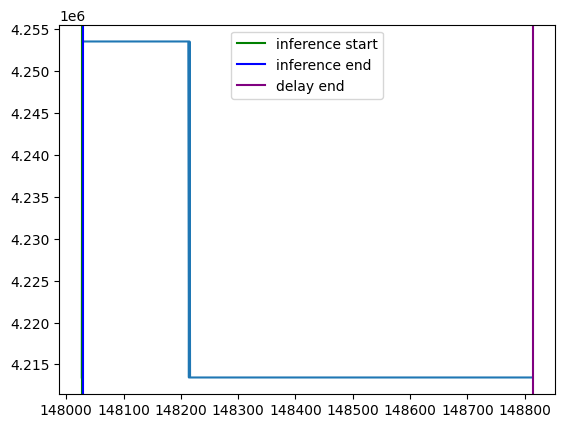

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:18.843767 -> 2025-01-22 14:30:18.846018
2025-01-22 14:30:19.846018
Time taken by inference cycle 8: 0:00:00.002251
Iteration: 8, Power index: 148816 -> 148819
149604


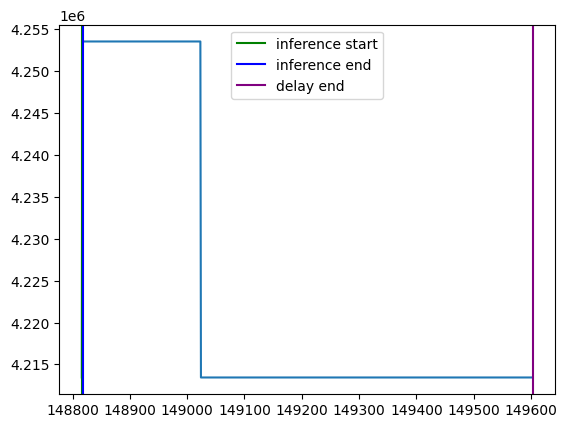

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:19.848362 -> 2025-01-22 14:30:19.850619
2025-01-22 14:30:20.850619
Time taken by inference cycle 9: 0:00:00.002257
Iteration: 9, Power index: 149605 -> 149607
150393


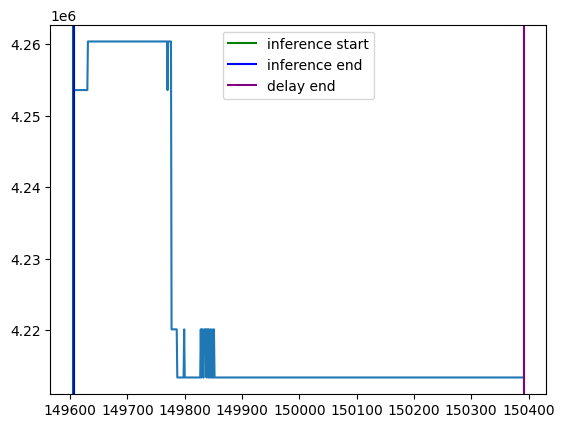

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:20.852938 -> 2025-01-22 14:30:20.855208
2025-01-22 14:30:21.855208
Time taken by inference cycle 10: 0:00:00.002270
Iteration: 10, Power index: 150393 -> 150396
151181


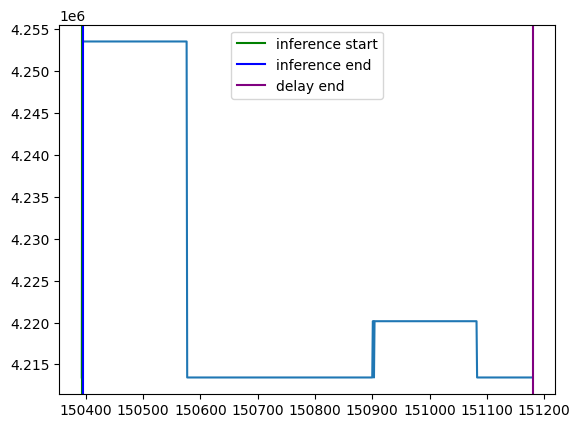

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:21.857584 -> 2025-01-22 14:30:21.859835
2025-01-22 14:30:22.859835
Time taken by inference cycle 11: 0:00:00.002251
Iteration: 11, Power index: 151182 -> 151185
151970


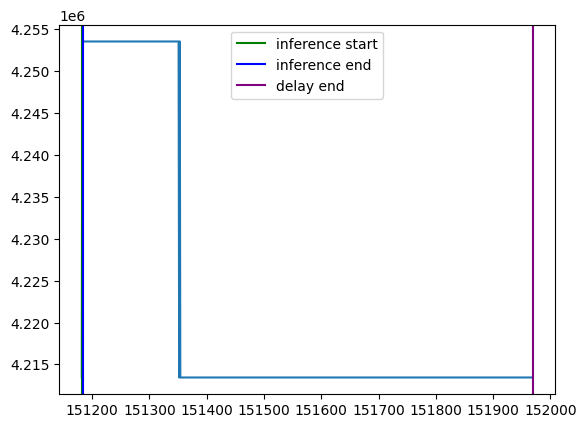

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:22.862116 -> 2025-01-22 14:30:22.864376
2025-01-22 14:30:23.864376
Time taken by inference cycle 12: 0:00:00.002260
Iteration: 12, Power index: 151970 -> 151973
152758


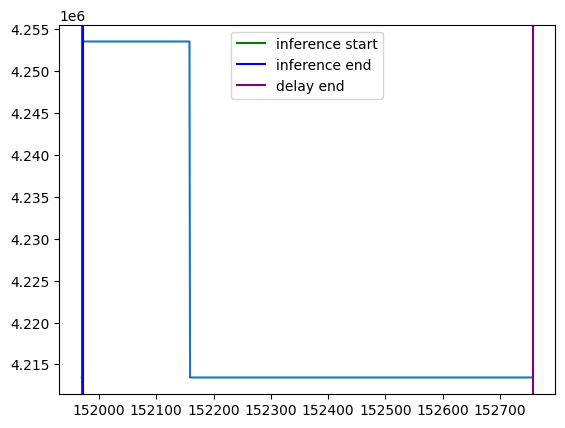

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:23.866696 -> 2025-01-22 14:30:23.868913
2025-01-22 14:30:24.868913
Time taken by inference cycle 13: 0:00:00.002217
Iteration: 13, Power index: 152759 -> 152762
153546


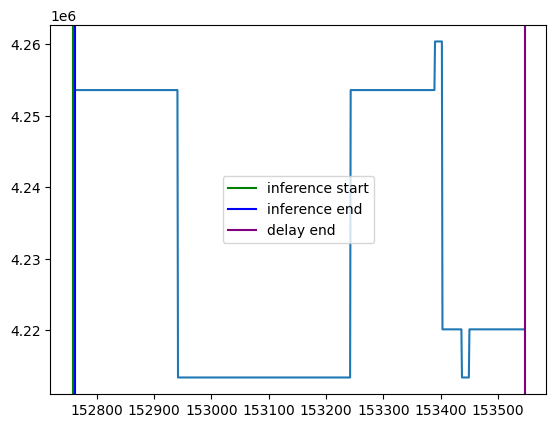

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4220160.0
----------------------------------------------------------------------------------------------------
2025-01-22 14:30:24.871377 -> 2025-01-22 14:30:24.873643
2025-01-22 14:30:25.873643
Time taken by inference cycle 14: 0:00:00.002266
Iteration: 14, Power index: 153547 -> 153549
154335


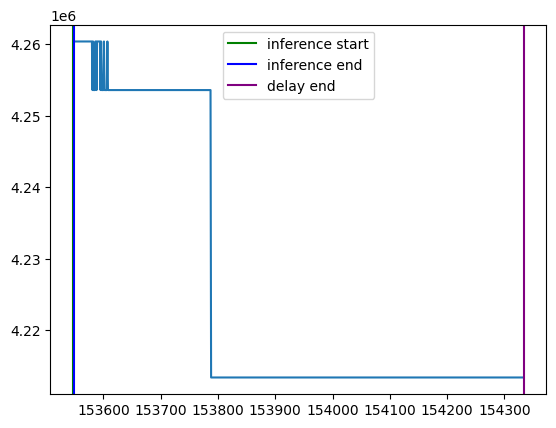

Power values:
Inference start: 4220160.0
Inference end: 4260352.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------


In [13]:
for i in range(15):
    plot_inference_cycle_power(i, alexnet_power_data, alexnet_latency_data, DELAY)